<a href="https://colab.research.google.com/github/DaniloRodrigues-DEV/exploracao-dados-governamentais-python/blob/main/gastos_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/Ano-2026.csv', sep= ';')
df.head()

/tmp/ipykernel_12632/3014756368.py:5: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Ano-2026.csv', sep= ';')


,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,numParcela,txtPassageiro,txtTrecho,numLote,numRessarcimento,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento
0,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2205670,NaN,NaN,NaN,2812,8044688,https://www.camara.leg.br/cota-parlamentar/doc...
1,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2212421,NaN,NaN,NaN,2812,8056691,https://www.camara.leg.br/cota-parlamentar/doc...
2,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2221943,NaN,NaN,NaN,2812,8073794,https://www.camara.leg.br/cota-parlamentar/doc...
3,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,3,COMBUSTÍVEIS E LUBRIFICANTES.,...,0,NaN,NaN,2201754,NaN,NaN,NaN,2812,8037989,https://www.camara.leg.br/cota-parlamentar/not...
4,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,3,COMBUSTÍVEIS E LUBRIFICANTES.,...,0,NaN,NaN,2201754,NaN,NaN,NaN,2812,8037990,https://www.camara.leg.br/cota-parlamentar/not...


In [ ]:
df.info()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.describe()

In [ ]:
colunas = ['txtFornecedor',
'txtDescricao', 'vlrLiquido', 'numMes']
df_combustivel = df[colunas]
df_combustivel = df_combustivel.query("txtDescricao == 'COMBUSTÍVEIS E LUBRIFICANTES.'")

df_combustivel.head()



,txtFornecedor,txtDescricao,vlrLiquido,numMes
3,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,COMBUSTÍVEIS E LUBRIFICANTES.,250.0,1
4,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,COMBUSTÍVEIS E LUBRIFICANTES.,150.0,1
5,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,COMBUSTÍVEIS E LUBRIFICANTES.,100.0,2
6,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,COMBUSTÍVEIS E LUBRIFICANTES.,200.0,2
7,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,COMBUSTÍVEIS E LUBRIFICANTES.,150.0,3


In [ ]:
fatura_fornecedor = df_combustivel.groupby('txtFornecedor') ['vlrLiquido'].sum()

fatura_fornecedor = fatura_fornecedor.sort_values(ascending = False)

fatura_fornecedor.head(4)

,vlrLiquido
txtFornecedor,
AUTO POSTO CINCO ESTRELAS LTDA,58847.20
LORENA COMERCIO DE PRODUTOS DE PETROLEO LTDA 000557,49501.18
031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,44392.18
063 - 311 SUL - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,37830.15


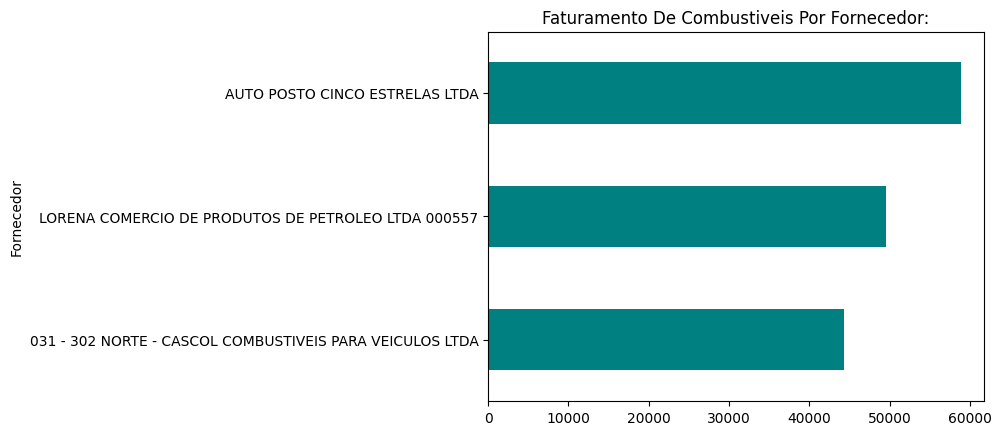

In [ ]:
fig, ax = plt.subplots()

fatura_fornecedor.head(3).plot(kind = 'barh', ax = ax, color = 'teal')

ax.set_title('Faturamento De Combustiveis Por Fornecedor:')
ax.set_ylabel('Fornecedor')
ax.invert_yaxis()

plt.show()